# Chapter 4 — Session 1
## Applied Statistics & Exploratory Analysis

## 0) Setup
Run this cell first.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

plt.rcParams["figure.figsize"] = (7, 4)

def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2)))

print("✅ Setup complete.")


✅ Setup complete.


## 1) Load a dataset
We will use a synthetic dataset that includes:
- linear relationship (study_hours → marks)
- non-linear relationship (x → x²)
- outliers
- missing values

In [22]:
rng = np.random.default_rng(42)
n = 250

study_hours = rng.normal(5, 2, n).clip(0)
sleep_hours = rng.normal(7, 1.2, n).clip(3, 10)
noise = rng.normal(0, 8, n)
marks = (10*study_hours + 2*sleep_hours + noise).clip(0, 100)

x_nonlinear = rng.uniform(-3, 3, n)
y_nonlinear = x_nonlinear**2 + rng.normal(0, 0.8, n)

df = pd.DataFrame({
    "study_hours": study_hours,
    "sleep_hours": sleep_hours,
    "marks": marks,
    "x_nonlinear": x_nonlinear,
    "y_nonlinear": y_nonlinear
})

# Outliers
outlier_idx = rng.choice(n, size=3, replace=False)
df.loc[outlier_idx, "marks"] = df["marks"].max() + rng.integers(30, 60, size=3)

# Missing values
missing_idx = rng.choice(n, size=8, replace=False)
df.loc[missing_idx, "sleep_hours"] = np.nan

df.head()


,study_hours,sleep_hours,marks,x_nonlinear,y_nonlinear
0,5.609434,6.558101,80.121442,-1.474419,2.456088
1,2.920032,7.409867,51.181531,2.512762,6.927432
2,6.500902,9.074437,77.402056,-0.273255,0.171611
3,6.881129,5.815772,68.422810,0.620547,0.489690
4,1.097930,6.705667,0.674399,2.907897,9.114869


### Quick baseline EDA
**STOP & DISCUSS:** What do you notice about missing values and column types?

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  250 non-null    float64
 1   sleep_hours  242 non-null    float64
 2   marks        250 non-null    float64
 3   x_nonlinear  250 non-null    float64
 4   y_nonlinear  250 non-null    float64
dtypes: float64(5)
memory usage: 9.9 KB


In [24]:
df.isna().sum().to_frame('missing_count')

,missing_count
study_hours,0
sleep_hours,8
marks,0
x_nonlinear,0
y_nonlinear,0


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
study_hours,250.0,4.902699,1.881680,0.705422,3.543761,4.787567,6.047044,10.827725
sleep_hours,242.0,7.036559,1.152997,3.920010,6.319553,7.110188,7.739882,10.000000
marks,250.0,62.893970,21.726639,0.674399,47.420814,61.448523,75.945546,157.000000
x_nonlinear,250.0,0.044192,1.762168,-2.986147,-1.484260,0.008398,1.543157,2.960211
y_nonlinear,250.0,3.093028,2.796416,-1.691760,0.825384,2.396353,5.298655,10.162803


---
## 2) Statistical Measures
We’ll cover: **Correlation**, **Covariance**, **Skewness**, **Kurtosis**.

**Rule:** Never trust a single number—validate with plots.

### 2.1 Correlation
- Measures strength + direction of **linear** relationship
- Range: -1 to +1
- Correlation ≠ causation

**Predict:** What happens to correlation if we add one extreme outlier?

In [26]:
df.corr(numeric_only=True)

,study_hours,sleep_hours,marks,x_nonlinear,y_nonlinear
study_hours,1.000000,0.031102,0.793577,0.001147,0.000307
sleep_hours,0.031102,1.000000,0.194385,-0.080821,-0.062229
marks,0.793577,0.194385,1.000000,0.020408,-0.004392
x_nonlinear,0.001147,-0.080821,0.020408,1.000000,0.078517
y_nonlinear,0.000307,-0.062229,-0.004392,0.078517,1.000000


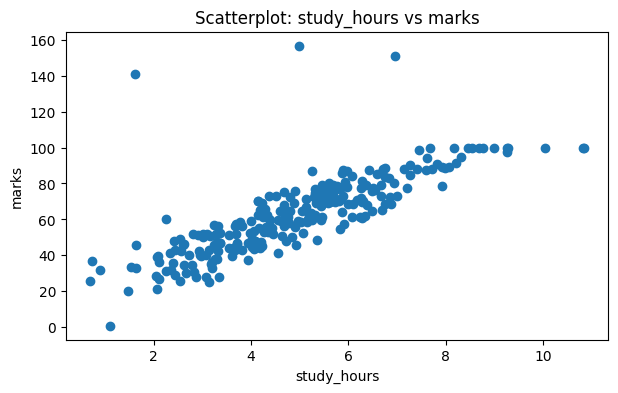

Correlation (study_hours, marks) = 0.7935773027628846


In [27]:
clean = df[["study_hours", "marks"]].dropna()

plt.scatter(clean["study_hours"], clean["marks"])
plt.xlabel("study_hours")
plt.ylabel("marks")
plt.title("Scatterplot: study_hours vs marks")
plt.show()

print("Correlation (study_hours, marks) =", clean["study_hours"].corr(clean["marks"]))


#### Practice 1 (Pairs) — Outlier attack (5–7 min)
1) Create `df_out` as a copy of `df`.
2) Add **one extreme outlier** row (you choose values).
3) Compute correlation before/after.
4) Plot scatterplot with outlier.

**Deliverable:** Write 2 sentences: what changed + why.


In [28]:
# TODO: complete this cell
df_out = df.copy()

# TODO: add one outlier row
# Example idea: low study_hours but very high marks, OR high study_hours but very low marks

# TODO: compute correlations
# old_corr = ...
# new_corr = ...

# TODO: plot scatterplot with outlier and print correlations


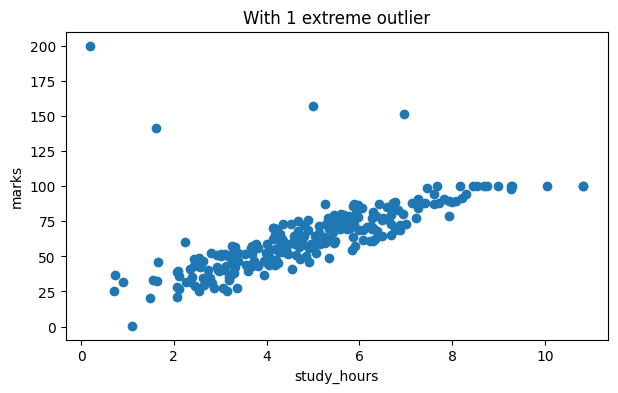

Old corr = 0.7935773027628846
New corr = 0.6701314136924768


In [29]:

df_out = df.copy()
df_out.loc[len(df_out)] = {"study_hours": 0.2, "sleep_hours": 7.0, "marks": 200.0, "x_nonlinear": 0.0, "y_nonlinear": 0.0}

base = df[["study_hours","marks"]].dropna()
base2 = df_out[["study_hours","marks"]].dropna()
old_corr = base["study_hours"].corr(base["marks"])
new_corr = base2["study_hours"].corr(base2["marks"])

plt.scatter(base2["study_hours"], base2["marks"])
plt.xlabel("study_hours")
plt.ylabel("marks")
plt.title("With 1 extreme outlier")
plt.show()

print("Old corr =", old_corr)
print("New corr =", new_corr)


### 2.2 Covariance
- Tells whether variables move together (sign)
- Magnitude depends on **units**, so it’s harder to interpret

**Question:** Why is covariance harder to interpret than correlation?

#### Covariance vs Correlation

| Aspect | Covariance | Correlation |
|--------|------------|-------------|
| **Units** | Has units (e.g., "hours × points") | Unitless |
| **Range** | −∞ to +∞ | −1 to +1 |
| **Interpretability** | Value of 50 = ? | 0.8 = strong, 0.3 = weak |

##### Formula

$$r = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y}$$

##### Key Takeaway

Correlation is covariance **standardized** by the standard deviations, giving a universal −1 to +1 scale that's easy to interpret regardless of variable units.

In [30]:
df.cov(numeric_only=True)

,study_hours,sleep_hours,marks,x_nonlinear,y_nonlinear
study_hours,3.540720,0.067867,32.443489,0.003803,0.001614
sleep_hours,0.067867,1.329403,4.893943,-0.164291,-0.201735
marks,32.443489,4.893943,472.046858,0.781336,-0.266847
x_nonlinear,0.003803,-0.164291,0.781336,3.105236,0.386914
y_nonlinear,0.001614,-0.201735,-0.266847,0.386914,7.819945


### 2.3 Correlation can miss non-linear relationships
Below, **y ≈ x²**. The relationship is strong, but correlation may be near 0.

### If r ≈ 0, What Can Still Be True?

Correlation only measures **linear** relationships. A correlation near 0 means "no *linear* relationship" — **not** "no relationship."

### Two Possibilities When r ≈ 0

| Scenario | What it looks like |
|----------|-------------------|
| **No relationship** | Random scatter |
| **Non-linear relationship** | Clear curved pattern (U-shape, wave, etc.) |

### The y = x² Example

The positive and negative sides of x both produce positive y values, so the linear trends **cancel out** → r ≈ 0, despite a perfect functional relationship.

### Key Takeaway

> **Always plot your data!** A scatterplot reveals patterns that correlation misses.

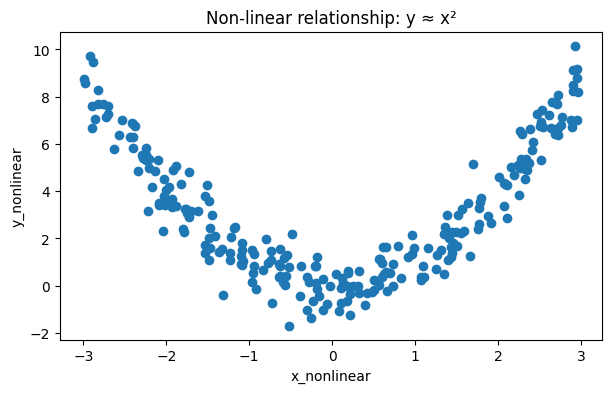

Correlation (x_nonlinear, y_nonlinear) = 0.07851734555069852


In [31]:
plt.scatter(df["x_nonlinear"], df["y_nonlinear"])
plt.xlabel("x_nonlinear")
plt.ylabel("y_nonlinear")
plt.title("Non-linear relationship: y ≈ x²")
plt.show()

print("Correlation (x_nonlinear, y_nonlinear) =", df["x_nonlinear"].corr(df["y_nonlinear"]))


### 2.4 Skewness
- Skewness describes asymmetry
- Right skew: tail right (often mean > median)

**Practice:** Is `marks` skewed? Use plot + skewness value.

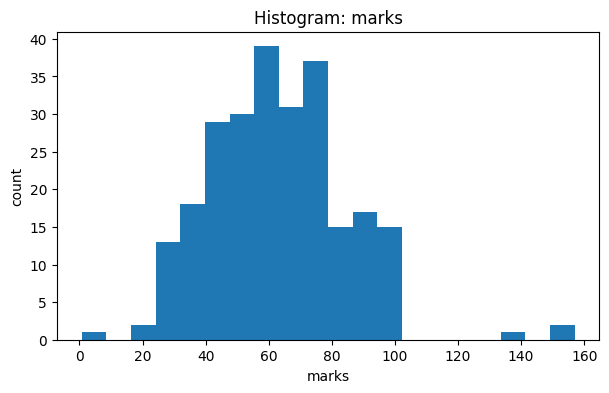

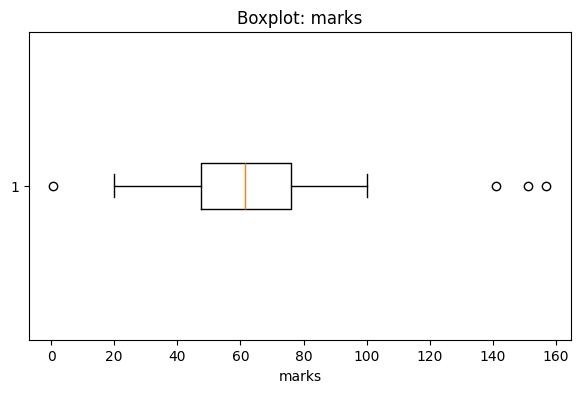

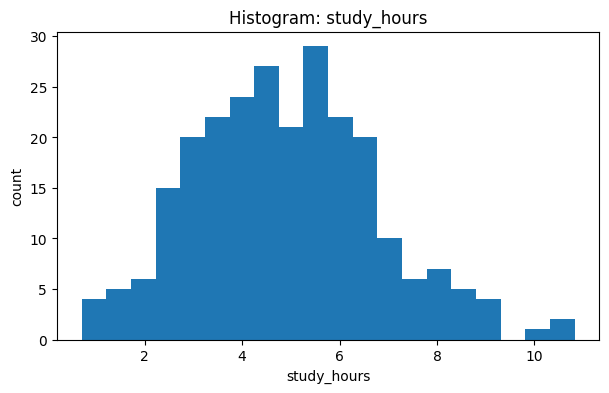

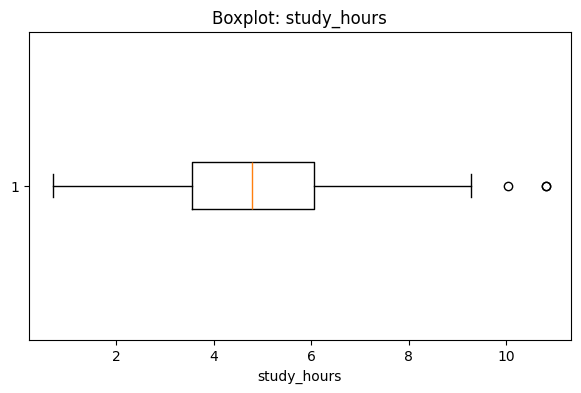

In [32]:
def hist_box(series, name):
    s = series.dropna()
    plt.hist(s, bins=20)
    plt.title(f"Histogram: {name}")
    plt.xlabel(name)
    plt.ylabel("count")
    plt.show()

    plt.boxplot(s, vert=False)
    plt.title(f"Boxplot: {name}")
    plt.xlabel(name)
    plt.show()

hist_box(df["marks"], "marks")
hist_box(df["study_hours"], "study_hours")


In [33]:
df[["marks","study_hours","sleep_hours"]].skew(numeric_only=True)

marks          0.654125
study_hours    0.387033
sleep_hours   -0.147367
dtype: float64

## Interpreting Skewness Values

| Column | Skewness | Interpretation |
|--------|----------|----------------|
| `marks` | **0.65** | Moderate **right skew** — tail extends right, mean > median |
| `study_hours` | **0.39** | Slight **right skew** — mild asymmetry to the right |
| `sleep_hours` | **-0.15** | Nearly **symmetric** — very slight left skew |

### Quick Reference

| Skewness Value | Shape |
|----------------|-------|
| < -1 | Highly left-skewed |
| -1 to -0.5 | Moderately left-skewed |
| -0.5 to 0.5 | Approximately symmetric |
| 0.5 to 1 | Moderately right-skewed |
| > 1 | Highly right-skewed |

### Key Insight

- **marks (0.65)**: Outliers with unusually high scores pull the mean up
- **Right skew** → mean > median → consider using **median** for central tendency

### 2.5 Kurtosis
- Higher kurtosis → heavier tails / more extreme values
- Think: “outlier tendency”

**Practice:** Which column seems most outlier-prone? Support with kurtosis + plot.

In [34]:
df[["marks","study_hours","sleep_hours"]].kurtosis(numeric_only=True)

marks          1.935141
study_hours    0.163951
sleep_hours   -0.113721
dtype: float64

## Interpreting Kurtosis Values

| Column | Kurtosis | Interpretation |
|--------|----------|----------------|
| `marks` | **1.94** | **High kurtosis** — heavier tails, more extreme values (outliers) |
| `study_hours` | **0.16** | Near **normal** — close to a standard bell curve |
| `sleep_hours` | **-0.11** | Slightly **platykurtic** — lighter tails than normal |

### Quick Reference (Excess Kurtosis)

| Kurtosis Value | Shape | Meaning |
|----------------|-------|---------|
| > 1 | **Leptokurtic** | Heavy tails, more outliers |
| ≈ 0 | **Mesokurtic** | Normal distribution |
| < 0 | **Platykurtic** | Light tails, fewer outliers |

### Key Insight

- **marks (1.94)** is the most **outlier-prone** column — confirms those extreme scores we added earlier
- High kurtosis = "fat tails" = more data points far from the mean

> **Tip:** Kurtosis measures "tail heaviness" — think of it as **outlier tendency**

---
## 3) Probability + Sampling (Conceptual)
### Quick discussion prompts
1) Population vs sample: what’s the difference?
2) What is sampling bias?
3) When would you use stratified sampling?

**Practice (write 3–4 lines):**
- You need student feedback across departments. Pick a sampling method and justify.


In [35]:
answer_sampling = """
Your answer:
"""
print(answer_sampling)



Your answer:



In [36]:

print("Example: Stratified sampling by department ensures each department is represented in proportion.")


Example: Stratified sampling by department ensures each department is represented in proportion.


---
## 4) Hypothesis Testing (Workflow)
Steps:
1) State **H₀** and **H₁**
2) Choose α
3) Compute p-value
4) Decide: reject H₀ or fail to reject H₀

**Key:** p-value = probability of results this extreme **assuming H₀ is true**.

### Practice 2 — Set up H₀/H₁
Claim: “A new teaching method increases average marks beyond 60.”

Write:
- H₀: ___
- H₁: ___


In [37]:
# TODO
H0 = ""
H1 = ""
print("H0:", H0)
print("H1:", H1)


H0: 
H1: 


In [38]:

print("H0: mu = 60")
print("H1: mu > 60")


H0: mu = 60
H1: mu > 60


### Practice 3 — Compute p-value (CLT-based approximation)
**Scenario:** Test whether mean is different from μ₀=60 (two-sided).
- Take a sample from `marks`
- Compute z-score
- Compute two-sided p-value


In [39]:
sample = df["marks"].dropna().sample(40, random_state=1)
mu0 = 60
sample_mean = sample.mean()
sample_std = sample.std(ddof=1)
n = len(sample)

print("sample_mean =", round(sample_mean, 3))
print("sample_std  =", round(sample_std, 3))
print("n =", n)


sample_mean = 54.696
sample_std  = 21.904
n = 40


In [40]:
# TODO: Compute z-score
z = None
z


In [41]:
# TODO: Compute two-sided p-value
p_two_sided = None
p_two_sided


In [42]:
# TODO: Decision rule
alpha = 0.05
decision = None
print(f"alpha={alpha}, p={p_two_sided} => {decision}")


alpha=0.05, p=None => None


In [43]:
z = (sample_mean - mu0) / (sample_std / np.sqrt(n))
p_two_sided = 2 * (1 - norm_cdf(abs(z)))
alpha = 0.05
decision = "REJECT H0" if p_two_sided <= alpha else "FAIL TO REJECT H0"
print("z =", z)
print("p =", p_two_sided)
print(f"alpha={alpha} => {decision}")

z = -1.5313846333910832
p = 0.12567435963637386
alpha=0.05 => FAIL TO REJECT H0


---
## 5) Simulation: Type I error (α = 0.05)
**Idea:** If H₀ is true and α=0.05, we’ll falsely reject about 5% of the time.

### Practice 4 — Complete the simulation
Fill in `run_one_test()` to:
1) generate data where H₀ is true
2) compute p-value
3) return True if p ≤ α


In [44]:
rng = np.random.default_rng(123)
mu0 = 60
sigma = 10
n = 40
trials = 2000
alpha = 0.05

def run_one_test():
    # TODO:
    # x = rng.normal(mu0, sigma, n)
    # z = ...
    # p = ...
    # return p <= alpha
    return None

rejects = 0
for _ in range(trials):
    if run_one_test():
        rejects += 1

false_positive_rate = rejects / trials
false_positive_rate


0.0

In [45]:
rng = np.random.default_rng(123)
mu0 = 60
sigma = 10
n = 40
trials = 2000
alpha = 0.05

def run_one_test():
    x = rng.normal(mu0, sigma, n)
    z = (x.mean() - mu0) / (x.std(ddof=1) / np.sqrt(n))
    p = 2 * (1 - norm_cdf(abs(z)))
    return p <= alpha

rejects = sum(run_one_test() for _ in range(trials))
false_positive_rate = rejects / trials
print("False positive rate ≈", false_positive_rate)


False positive rate ≈ 0.049


---
## 6) Practice Questions
Answer directly in this notebook (markdown or code).

### A) Conceptual (short answers)
1. Correlation is -0.8 between X and Y. What does this mean in words?
2. Give one example where mean is misleading and median is better.
3. If correlation is ~0, name **two** possibilities.
4. Define covariance in one sentence and explain why units matter.
5. Explain skewness using mean/median order for right-skew.
6. What does a p-value mean (correct definition)?
7. What does α control?
8. Why do we say “fail to reject H₀” instead of “accept H₀”?


### B) Quick MCQs
Choose one option (write A/B/C/D):
1) Correlation measures: A) causation B) linear association C) non-linear association D) variance
2) A right-skewed distribution typically has: A) mean < median B) mean ≈ median C) mean > median D) none
3) If p = 0.03 and α = 0.05, we: A) accept H₀ B) reject H₀ C) increase α D) cannot decide
4) Stratified sampling is best when: A) population has subgroups B) data is time-ordered C) clusters are cheap D) you want bias


### C) Coding practice
1) Write a function `robust_summary(s)` that returns mean, median, std, IQR.
2) Find the **top 2** highest-correlation pairs in `df` (ignore self-correlation).
3) Create 3 scatterplots among `study_hours`, `sleep_hours`, and `marks`.


In [46]:
# TODO C1
def robust_summary(s: pd.Series) -> dict:
    return {}

print(robust_summary(df["marks"]))


{}


In [47]:
# TODO C2: top 2 correlation pairs (hint: use stack + sort)
corr = df.corr(numeric_only=True).abs()
corr


,study_hours,sleep_hours,marks,x_nonlinear,y_nonlinear
study_hours,1.000000,0.031102,0.793577,0.001147,0.000307
sleep_hours,0.031102,1.000000,0.194385,0.080821,0.062229
marks,0.793577,0.194385,1.000000,0.020408,0.004392
x_nonlinear,0.001147,0.080821,0.020408,1.000000,0.078517
y_nonlinear,0.000307,0.062229,0.004392,0.078517,1.000000


In [48]:
# TODO C3
cols = ["study_hours", "sleep_hours", "marks"]
# Create 3 scatter plots: (study_hours, sleep_hours), (study_hours, marks), (sleep_hours, marks)
